<a href="https://colab.research.google.com/github/vitaoTM/100-days-of-code/blob/coding/Data_extraction_MOMS_B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extraindo Negociações 2025 e Criando um pandas DataFrame

In [ ]:
import pandas as pd
# é importante ter colocar os mesmos nomes nos arquivos e na chamada de função
df_negociacoes = pd.read_excel('/content/Negociações.xlsx')
display(df_negociacoes)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Data do Negócio,Tipo de Movimentação,Mercado,Prazo/Vencimento,Instituição,Código de Negociação,Quantidade,Preço,Valor
0,28/11/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CCTVM S/A,ALZR11,25,10.70,267.50
1,28/11/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CCTVM S/A,GGRC11,70,9.91,693.70
2,28/11/2025,Compra,Mercado Fracionário,-,XP INVESTIMENTOS CCTVM S/A,GRND3F,45,4.98,224.10
3,28/11/2025,Compra,Mercado à Vista,28/11/2025,XP INVESTIMENTOS CCTVM S/A,VGHF11,130,7.19,934.70
4,28/11/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CCTVM S/A,XPML11,4,106.77,427.08
...,...,...,...,...,...,...,...,...,...
156,24/01/2025,Compra,Mercado à Vista,-,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",VGHF11,100,7.16,716.00
157,08/01/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,BERK34,2,138.40,276.80
158,08/01/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,KISU11,7,6.93,48.51
159,08/01/2025,Compra,Mercado à Vista,-,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,VGHF11,24,7.54,180.96


 ### Criando Tabelas de negociação para cada mês de 2025

In [ ]:
import pandas as pd

# Convert 'Data do Negócio' to datetime objects
df_negociacoes['Data do Negócio'] = pd.to_datetime(df_negociacoes['Data do Negócio'], format='%d/%m/%Y')

# Extract month and year for grouping
df_negociacoes['Ano_Mes'] = df_negociacoes['Data do Negócio'].dt.to_period('M')

# Get unique months for iteration and sort them
meses_unicos = pd.PeriodIndex(df_negociacoes['Ano_Mes'].unique()).sort_values()

# Iterate through each unique month and create a table
for ano_mes in meses_unicos:
    # Filter data for the current month
    df_mes = df_negociacoes[df_negociacoes['Ano_Mes'] == ano_mes].copy()

    # Group by asset name and aggregate quantities and prices
    df_grouped_month = df_mes.groupby('Código de Negociação').agg(
        {
            'Quantidade': 'sum',
            'Preço': 'mean',
            'Tipo de Movimentação': 'first',
            'Mercado': 'first',
            'Data do Negócio': 'first' # Take the first date to represent the month
        }
    ).reset_index()

    # Format 'Data do Negócio' to show only month and year after aggregation
    df_grouped_month['Data do Negócio'] = df_grouped_month['Data do Negócio'].dt.strftime('%m/%Y')

    # Recalculate 'Valor' based on aggregated 'Quantidade' and 'Preço'
    df_grouped_month['Valor'] = df_grouped_month['Quantidade'] * df_grouped_month['Preço']

    # Round 'Preço' and 'Valor' to two decimal places for display
    df_grouped_month['Preço'] = df_grouped_month['Preço'].round(2)
    df_grouped_month['Valor'] = df_grouped_month['Valor'].round(2)

    # Select and reorder columns for display
    df_mes_display = df_grouped_month[[
        'Data do Negócio',
        'Tipo de Movimentação',
        'Mercado',
        'Código de Negociação',
        'Quantidade',
        'Preço',
        'Valor'
    ]]

    # Calculate the total negotiated value for the month from the aggregated table
    total_mes = df_mes_display['Valor'].sum()

    # Create a DataFrame for the total row
    # It needs 5 empty strings before 'total_mes' to match the 7 columns of df_mes_display
    df_total = pd.DataFrame([['Total do Mês', '', '', '', '', '', total_mes]],
                            columns=df_mes_display.columns)

    # Append the total row to the monthly DataFrame
    df_mes_final = pd.concat([df_mes_display, df_total], ignore_index=True)

    # Display the table for the current month
    print(f"### Negociações para {ano_mes.strftime('%B/%Y')}")
    display(df_mes_final)
    print("\n" + "-"*50 + "\n") # Separator for readability

### Negociações para January/2025


,Data do Negócio,Tipo de Movimentação,Mercado,Código de Negociação,Quantidade,Preço,Valor
0,01/2025,Compra,Mercado à Vista,BERK34,7,137.07,959.52
1,01/2025,Compra,Mercado à Vista,KISU11,7,6.93,48.51
2,01/2025,Compra,Mercado à Vista,RZTR11,4,82.4,329.60
3,01/2025,Compra,Mercado à Vista,SNCI11,20,82.08,1641.52
4,01/2025,Compra,Mercado à Vista,VGHF11,240,7.42,1780.00
5,Total do Mês,,,,,,4759.15



--------------------------------------------------

### Negociações para April/2025


,Data do Negócio,Tipo de Movimentação,Mercado,Código de Negociação,Quantidade,Preço,Valor
0,04/2025,Compra,Mercado à Vista,ALZR11,25,100.84,2520.88
1,04/2025,Compra,Mercado à Vista,BERK34,40,150.87,6034.80
2,04/2025,Compra,Mercado à Vista,GGRC11,50,9.89,494.50
3,04/2025,Compra,Mercado à Vista,HGRE11,15,112.86,1692.90
4,04/2025,Compra,Mercado à Vista,JSRE11,50,58.42,2920.92
5,04/2025,Compra,Mercado Fracionário,MGLU3F,82,10.41,853.62
6,04/2025,Compra,Mercado à Vista,RZTR11,19,88.1,1674.00
7,04/2025,Compra,Mercado à Vista,SNAG11,190,9.27,1761.30
8,04/2025,Compra,Mercado à Vista,VGHF11,500,7.6,3800.00
9,04/2025,Compra,Mercado à Vista,VISC11,20,101.87,2037.40



--------------------------------------------------

### Negociações para May/2025


...


--------------------------------------------------

### Negociações para October/2025


,Data do Negócio,Tipo de Movimentação,Mercado,Código de Negociação,Quantidade,Preço,Valor
0,10/2025,Compra,Mercado à Vista,HGRE11,40,117.65,4706.0
1,10/2025,Compra,Mercado à Vista,KISU11,60,6.76,405.6
2,10/2025,Compra,Mercado à Vista,SNAG11,60,9.57,574.2
3,10/2025,Compra,Mercado à Vista,SNCI11,40,80.68,3227.4
4,10/2025,Compra,Mercado à Vista,VGHF11,110,7.65,841.5
5,Total do Mês,,,,,,9754.7



--------------------------------------------------

### Negociações para November/2025


,Data do Negócio,Tipo de Movimentação,Mercado,Código de Negociação,Quantidade,Preço,Valor
0,11/2025,Compra,Mercado à Vista,ALZR11,25,10.7,267.50
1,11/2025,Compra,Mercado à Vista,GGRC11,70,9.91,693.70
2,11/2025,Compra,Mercado Fracionário,GRND3F,45,4.98,224.10
3,11/2025,Compra,Mercado à Vista,VGHF11,130,7.19,934.70
4,11/2025,Compra,Mercado à Vista,XPML11,15,106.78,1601.62
5,Total do Mês,,,,,,3721.62



--------------------------------------------------



### Tabela de negociações com a média de valores pro ano

In [ ]:
import pandas as pd

# Ensure 'Data do Negócio' is in datetime format
df_negociacoes['Data do Negócio'] = pd.to_datetime(df_negociacoes['Data do Negócio'], format='%d/%m/%Y')

# Filter for the year 2025
df_2025 = df_negociacoes[df_negociacoes['Data do Negócio'].dt.year == 2025].copy()

# Group by asset name and aggregate quantities and prices for the entire year
df_grouped_2025 = df_2025.groupby('Código de Negociação').agg(
    {
        'Quantidade': 'sum',
        'Preço': 'mean',
        'Tipo de Movimentação': 'first',
        'Mercado': 'first',
        'Data do Negócio': lambda x: '2025' # Represent the year
    }
).reset_index()

# Rename 'Data do Negócio' to 'Ano' as it now represents the year
df_grouped_2025 = df_grouped_2025.rename(columns={'Data do Negócio': 'Ano'})

# Recalculate 'Valor' based on aggregated 'Quantidade' and 'Preço'
df_grouped_2025['Valor'] = df_grouped_2025['Quantidade'] * df_grouped_2025['Preço']

# Round 'Preço' and 'Valor' to two decimal places for display
df_grouped_2025['Preço'] = df_grouped_2025['Preço'].round(2)
df_grouped_2025['Valor'] = df_grouped_2025['Valor'].round(2)

# Select and reorder columns for display
df_2025_display = df_grouped_2025[[
    'Ano',
    'Tipo de Movimentação',
    'Mercado',
    'Código de Negociação',
    'Quantidade',
    'Preço',
    'Valor'
]]

# Calculate the total negotiated value for the year
total_ano = df_2025_display['Valor'].sum().round(2)

# Create a DataFrame for the total row
# It needs 5 empty strings before 'total_ano' to match the 7 columns of df_2025_display
df_total_row = pd.DataFrame([['Total do Ano', '', '', '', '', '', total_ano]],
                            columns=df_2025_display.columns)

# Append the total row to the yearly DataFrame
df_2025_final = pd.concat([df_2025_display, df_total_row], ignore_index=True)

print("### Negociações para o Ano de 2025 (Agregado)")
display(df_2025_final)

### Negociações para o Ano de 2025 (Agregado)


,Ano,Tipo de Movimentação,Mercado,Código de Negociação,Quantidade,Preço médio,Valor
0,2025,Compra,Mercado à Vista,ALZR11,1090,30.36,33088.77
1,2025,Compra,Mercado à Vista,BERK34,141,139.26,19635.31
2,2025,Compra,Mercado à Vista,DISB34,15,35.22,528.30
3,2025,Compra,Mercado à Vista,GGRC11,740,9.86,7293.62
4,2025,Compra,Mercado Fracionário,GRND3F,129,5.19,669.25
5,2025,Compra,Mercado à Vista,HGRE11,104,113.79,11834.10
6,2025,Compra,Mercado à Vista,JSRE11,100,59.86,5986.44
7,2025,Compra,Mercado à Vista,KISU11,235,6.88,1617.81
8,2025,Compra,Mercado à Vista,KNRI11,18,143.54,2583.66
9,2025,Compra,Mercado Fracionário,MGLU3F,165,9.45,1559.58


## Extraindo relatorio-consolidado-anual-2025 (Ações)

In [ ]:
import pandas as pd
df_relatorio_consolidado = pd.read_excel('/content/relatorio-consolidado-anual-2025.xlsx')
df_relatorio_consolidado['CNPJ da Empresa'] = df_relatorio_consolidado['CNPJ da Empresa'].astype(pd.Int64Dtype()).astype(str)
df_relatorio_consolidado.dropna(inplace=True)
display(df_relatorio_consolidado.head(7))

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Produto,Instituição,Conta,Código de Negociação,CNPJ da Empresa,Código ISIN / Distribuição,Tipo,Escriturador,Quantidade,Quantidade Disponível,Quantidade Indisponível,Motivo,Preço de Fechamento,Valor Atualizado
0,"B3SA3 - B3 S.A. - BRASIL, BOLSA, BALCÃO ...",XP INVESTIMENTOS CCTVM S/A,12049626.0,B3SA3,9346601000125,BRB3SAACNOR6 - 139,ON,BANCO BRADESCO S/A,197.00,197.00,-,-,13.89,2736.33
1,EGIE3 - ENGIE BRASIL ENERGIA S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,EGIE3,2474103000119,BREGIEACNOR9 - 132,ON,ITAU CV S/A,175.00,175.00,-,-,31.37,5489.75
2,GRND3 - GRENDENE S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,GRND3,89850341000160,BRGRNDACNOR3 - 182,ON,BTG PACTUAL SERVICOS FINANCEIROS S/A DTVM,390.00,390.00,-,-,4.60,1794
3,ITSA4 - ITAUSA S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,ITSA4,61532644000115,BRITSAACNPR7 - 455,PN,ITAU CV S/A,345.78,345.78,-,-,11.68,4038.71
4,MGLU3 - MAGAZINE LUIZA S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,MGLU3,47960950000121,BRMGLUACNOR2 - 129,ON,BTG PACTUAL SERVICOS FINANCEIROS S/A DTVM,265.00,265.00,-,-,9.39,2488.35
5,RADL3 - RAIA DROGASIL S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,RADL3,61585865000151,BRRADLACNOR0 - 165,ON,ITAU CV S/A,213.18,213.18,-,-,23.45,4999.07
6,WEGE3 - WEG S.A. ...,XP INVESTIMENTOS CCTVM S/A,12049626.0,WEGE3,84429695000111,BRWEGEACNOR0 - 234,ON,BANCO BRADESCO S/A,326.00,326.00,-,-,48.51,15814.26


## Extraindo Movimentação para um pandas DataFrame

In [ ]:
import pandas as pd
df_movimentacao = pd.read_excel('/content/Movimentação.xlsx')
display(df_movimentacao)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Entrada/Saída,Data,Movimentação,Produto,Instituição,Quantidade,Preço unitário,Valor da Operação
0,Credito,29/12/2025,Dividendo,RADL3 - RAIA DROGASIL S.A.,XP INVESTIMENTOS CCTVM S/A,209.00,0.076,15.86
1,Credito,26/12/2025,Juros Sobre Capital Próprio,GRND3 - GRENDENE S/A,XP INVESTIMENTOS CCTVM S/A,390.00,0.05,16.54
2,Credito,26/12/2025,Dividendo,GRND3 - GRENDENE S/A,XP INVESTIMENTOS CCTVM S/A,390.00,0.062,24.32
3,Credito,26/12/2025,Bonificação em Ativos,RADL3 - RAIA DROGASIL S.A.,XP INVESTIMENTOS CCTVM S/A,4.18,-,-
4,Credito,23/12/2025,Rendimento,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,XP INVESTIMENTOS CCTVM S/A,4815.00,0.084,402.29
...,...,...,...,...,...,...,...,...
541,Debito,02/01/2025,Transferência,RADL3 - RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
542,Credito,02/01/2025,Transferência,RADL3 - RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
543,Debito,02/01/2025,Transferência - Liquidação,RADL3 - RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
544,Credito,02/01/2025,Empréstimo,RADL3 - RAIA DROGASIL S.A. ...,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-


In [ ]:
split_data = df_movimentacao['Produto'].str.split(' - ', n=1, expand=True)

df_movimentacao['Ticker'] = split_data[0]
df_movimentacao['Nome da Empresa'] = split_data[1]

# Exclude the 'Produto' column
df_movimentacao = df_movimentacao.drop(columns=['Produto'])

# Define the desired column order
desired_order = [
    'Entrada/Saída',
    'Data',
    'Movimentação',
    'Ticker',
    'Nome da Empresa',
    'Instituição',
    'Quantidade',
    'Preço unitário',
    'Valor da Operação'
]

# Reorder the columns
df_movimentacao = df_movimentacao[desired_order]

display(df_movimentacao)

,Entrada/Saída,Data,Movimentação,Ticker,Nome da Empresa,Instituição,Quantidade,Preço unitário,Valor da Operação
0,Credito,29/12/2025,Dividendo,RADL3,RAIA DROGASIL S.A.,XP INVESTIMENTOS CCTVM S/A,209.00,0.076,15.86
1,Credito,26/12/2025,Juros Sobre Capital Próprio,GRND3,GRENDENE S/A,XP INVESTIMENTOS CCTVM S/A,390.00,0.05,16.54
2,Credito,26/12/2025,Dividendo,GRND3,GRENDENE S/A,XP INVESTIMENTOS CCTVM S/A,390.00,0.062,24.32
3,Credito,26/12/2025,Bonificação em Ativos,RADL3,RAIA DROGASIL S.A.,XP INVESTIMENTOS CCTVM S/A,4.18,-,-
4,Credito,23/12/2025,Rendimento,ALZR11,ALIANZA TRUST RENDA IMOBILIARIA FDO INV IMOB,XP INVESTIMENTOS CCTVM S/A,4815.00,0.084,402.29
...,...,...,...,...,...,...,...,...,...
541,Debito,02/01/2025,Transferência,RADL3,RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
542,Credito,02/01/2025,Transferência,RADL3,RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
543,Debito,02/01/2025,Transferência - Liquidação,RADL3,RAIA DROGASIL S.A.,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-
544,Credito,02/01/2025,Empréstimo,RADL3,RAIA DROGASIL S.A. ...,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,99.00,-,-


## Tabela mensal de movimentações

In [ ]:
import pandas as pd

# Ensure 'Data' column is in datetime format
df_movimentacao['Data'] = pd.to_datetime(df_movimentacao['Data'], format='%d/%m/%Y')

# Convert 'Preço unitário' and 'Valor da Operação' to numeric, coercing errors to NaN
df_movimentacao['Preço unitário'] = pd.to_numeric(df_movimentacao['Preço unitário'], errors='coerce')
df_movimentacao['Valor da Operação'] = pd.to_numeric(df_movimentacao['Valor da Operação'], errors='coerce')

# Extract month and year for grouping
df_movimentacao['Ano_Mes'] = df_movimentacao['Data'].dt.to_period('M')

# Get unique months for iteration and sort them
meses_unicos_mov = pd.PeriodIndex(df_movimentacao['Ano_Mes'].unique()).sort_values()

# Iterate through each unique month and create a table
for ano_mes_mov in meses_unicos_mov:
    # Filter data for the current month
    df_mes_mov = df_movimentacao[df_movimentacao['Ano_Mes'] == ano_mes_mov].copy()

    # Group by 'Nome da Empresa' and aggregate as requested (sum quantities, sum unit prices, sum operation values)
    df_grouped_month_mov = df_mes_mov.groupby('Nome da Empresa').agg(
        {
            'Entrada/Saída': 'first',
            'Data': 'first', # Will represent the month
            'Ticker': 'first',
            'Quantidade': 'sum',
            'Preço unitário': 'sum',
            'Valor da Operação': 'sum'
        }
    ).reset_index()

    # Format 'Data' to show only month and year after aggregation
    df_grouped_month_mov['Data'] = df_grouped_month_mov['Data'].dt.strftime('%m/%Y')

    # Round numeric columns to two decimal places for display
    df_grouped_month_mov['Preço unitário'] = df_grouped_month_mov['Preço unitário'].round(2)
    df_grouped_month_mov['Valor da Operação'] = df_grouped_month_mov['Valor da Operação'].round(2)

    # Define desired column order for display (excluding 'Instituição' and 'Movimentação')
    desired_display_order = [
        'Entrada/Saída',
        'Data',
        'Ticker',
        'Nome da Empresa',
        'Quantidade',
        'Preço unitário',
        'Valor da Operação'
    ]

    # Select and reorder columns for display
    df_mes_display_mov = df_grouped_month_mov[desired_display_order]

    # Calculate the total value of operation for the month from the aggregated table
    total_mes_operacao = df_mes_display_mov['Valor da Operação'].sum().round(2)

    # Create a DataFrame for the total row
    # It needs 5 empty strings before 'total_mes_operacao' to match the 7 columns of df_mes_display_mov
    df_total_mov = pd.DataFrame([['Total do Mês', '', '', '', '', '', total_mes_operacao]],
                                columns=df_mes_display_mov.columns)

    # Append the total row to the monthly DataFrame
    df_mes_final_mov = pd.concat([df_mes_display_mov, df_total_mov], ignore_index=True)

    # Display the table for the current month
    print(f"### Movimentações para {ano_mes_mov.strftime('%B/%Y')}")
    display(df_mes_final_mov)
    print("\n" + "-"*50 + "\n") # Separator for readability

### Movimentações para January/2025


,Entrada/Saída,Data,Ticker,Nome da Empresa,Quantidade,Preço unitário,Valor da Operação
0,Credito,01/2025,ALZR11,ALIANZA TRUST RENDA IMOBILIARIA FDO INV IMOB,350.0,0.81,281.92
1,Credito,01/2025,B3SA3,"B3 S.A. - BRASIL, BOLSA, BALCÃO",197.0,0.06,10.72
2,Credito,01/2025,BERK34,BERKSHIRE HATHAWAY INC.,7.0,274.15,955.55
3,Debito,01/2025,EGIE3,ENGIE BRASIL ENERGIA S.A.,375.0,0.0,0.00
4,Credito,01/2025,EGIE3,ENGIE BRASIL ENERGIA S.A. ...,125.0,0.0,0.00
5,Credito,01/2025,RZTR11,FUNDO DE INVESTIMENTO IMOBILIÁRIO RIZA TERRAX,249.0,83.5,599.10
6,Credito,01/2025,GGRC11,GGR COVEPI RENDA FII - RESPONSABILIDADE LIMITADA,1860.0,0.1,176.70
7,Credito,01/2025,ITSA4,ITAUSA S/A,323.3,9.09,7.81
8,Credito,01/2025,JSRE11,JS REAL ESTATE MULTIGESTÃO - FII,195.0,0.48,93.60
9,Credito,01/2025,KISU11,KILIMA FUNDO DE INVESTIMENTO EM COTAS DE FUNDO...,722.0,7.0,96.41



--------------------------------------------------

### Movimentações para February/2025


,Entrada/Saída,Data,Ticker,Nome da Empresa,Quantidade,Preço unitário,Valor da Operação
0,Credito,02/2025,ALZR11,ALIANZA TRUST RENDA IMOBILIARIA FDO INV IMOB,1750.0,2.42,845.76
1,Credito,02/2025,GOGL34,ALPHABET INC.,168.0,0.0,0.00
2,Credito,02/2025,AMZO34,"AMAZON.COM, INC",260.0,0.0,0.00
3,Credito,02/2025,B3SA3,"B3 S.A. - BRASIL, BOLSA, BALCÃO",394.0,0.0,0.00
4,Credito,02/2025,BERK34,BERKSHIRE HATHAWAY INC.,192.0,0.0,0.00
5,Credito,02/2025,EGIE3,ENGIE BRASIL ENERGIA S.A.,690.0,38.69,4762.25
6,Credito,02/2025,EGIE3,ENGIE BRASIL ENERGIA S.A. ...,125.0,0.0,2.24
7,Credito,02/2025,EVTC31,EVERTEC INC,2.0,0.0,0.00
8,Credito,02/2025,RZTR11,FUNDO DE INVESTIMENTO IMOBILIÁRIO RIZA TERRAX,747.0,1.05,261.45
9,Credito,02/2025,GGRC11,GGR COVEPI RENDA FII - RESPONSABILIDADE LIMITADA,5580.0,0.1,176.70



--------------------------------------------------

### Movimentações para March/2025


...


--------------------------------------------------

### Movimentações para November/2025


,Entrada/Saída,Data,Ticker,Nome da Empresa,Quantidade,Preço unitário,Valor da Operação
0,Credito,11/2025,ALZR11,ALIANZA TRUST RENDA IMOBILIARIA FDO INV IMOB,4790.0,0.08,400.20
1,Credito,11/2025,EGIE3,ENGIE BRASIL ENERGIA S.A.,50.0,0.0,0.00
2,Credito,11/2025,RZTR11,FUNDO DE INVESTIMENTO IMOBILIÁRIO RIZA TERRAX,345.0,1.0,345.00
3,Credito,11/2025,GGRC11,GGR COVEPI RENDA FII - RESPONSABILIDADE LIMITADA,2530.0,0.1,253.00
4,Credito,11/2025,JSRE11,JS REAL ESTATE MULTIGESTÃO - FII,295.0,0.48,141.60
5,Credito,11/2025,KISU11,KILIMA FIC FDO. IMOB. SUNO 30,1010.0,6.83,472.10
6,Credito,11/2025,KNRI11,KINEA RENDA IMOBILIÁRIA FDO INV IMOB - FII,240.0,1.0,240.00
7,Credito,11/2025,MXRF11,MAXI RENDA FDO INV IMOB - FII,373.0,0.1,37.30
8,Credito,11/2025,HGRE11,PÁTRIA ESCRITÓRIOS - FDO INV IMOB - RESPONSAB ...,340.0,118.5,4961.00
9,Credito,11/2025,HGLG11,PÁTRIA LOG - FDO INV IMOB - RESPONSABILIDADE L...,201.0,1.1,221.10



--------------------------------------------------

### Movimentações para December/2025


,Entrada/Saída,Data,Ticker,Nome da Empresa,Quantidade,Preço unitário,Valor da Operação
0,Credito,12/2025,ALZR11,ALIANZA TRUST RENDA IMOBILIARIA FDO INV IMOB,4840.0,10.78,669.79
1,Credito,12/2025,GOGL34,ALPHABET INC.,84.0,0.06,5.41
2,Credito,12/2025,EGIE3,ENGIE BRASIL ENERGIA S.A.,250.0,1.76,219.73
3,Credito,12/2025,EVTC31,EVERTEC INC,1.0,0.26,0.26
4,Credito,12/2025,RZTR11,FUNDO DE INVESTIMENTO IMOBILIÁRIO RIZA TERRAX,345.0,1.0,345.00
5,Credito,12/2025,GGRC11,GGR COVEPI RENDA FII - RESPONSABILIDADE LIMITADA,2670.0,10.01,953.70
6,Credito,12/2025,GRND3,GRENDENE S/A,1515.0,5.16,285.95
7,Credito,12/2025,ITSA4,ITAUSA S.A.,345.78,0.78,262.84
8,Credito,12/2025,JSRE11,JS REAL ESTATE MULTIGESTÃO - FII,295.0,0.48,141.60
9,Credito,12/2025,KISU11,KILIMA FIC FDO. IMOB. SUNO 30,950.0,0.07,66.50



--------------------------------------------------



## Tabelas com rendimentos mensais de Ações

### Extraindo proventos-recebidos 2025

In [ ]:
import pandas as pd
df_proventos = pd.read_excel('/content/proventos-recebidos-2025-12-21-a-2026-01-20.xlsx')
display(df_proventos)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,RADL3 - RAIA DROGASIL S.A.,29/12/2025,Dividendo,XP INVESTIMENTOS CCTVM S/A,209,0.08,15.86
1,GRND3 - GRENDENE S/A,26/12/2025,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,390,0.05,16.54
2,GRND3 - GRENDENE S/A,26/12/2025,Dividendo,XP INVESTIMENTOS CCTVM S/A,390,0.06,24.32
3,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,23/12/2025,Rendimento,XP INVESTIMENTOS CCTVM S/A,4.815,0.08,402.29
4,EGIE3 - ENGIE BRASIL ENERGIA S.A.,23/12/2025,Dividendo,XP INVESTIMENTOS CCTVM S/A,125,0.88,109.56
...,...,...,...,...,...,...,...
234,VGHF11 - VALORA HEDGE FUND FUNDO DE INVESTIMEN...,08/01/2025,Rendimento,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,470,0.09,42.3
235,ITSA4 - ITAUSA S/A,02/01/2025,Juros Sobre Capital Próprio,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,323,0.02,6.46
236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237,NaN,NaN,NaN,NaN,NaN,NaN,Total


## Tabelas com rendimentos mensais de FIIs

In [ ]:
import pandas as pd

# Ensure 'Pagamento' column is in datetime format
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for real estate funds (FIIs) based on keywords in 'Produto'
df_proventos_fii = df_proventos[df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Extract month and year for grouping, dropping NaT values
df_proventos_fii['Ano_Mes'] = df_proventos_fii['Pagamento'].dt.to_period('M')

# Get unique months for iteration and sort them, excluding any NaT values
meses_unicos_proventos = pd.PeriodIndex(df_proventos_fii['Ano_Mes'].dropna().unique()).sort_values()

# Iterate through each unique month and create a table
for ano_mes_prov in meses_unicos_proventos:
    # Filter data for the current month
    df_mes_proventos = df_proventos_fii[df_proventos_fii['Ano_Mes'] == ano_mes_prov].copy()

    # Drop the 'Ano_Mes' column as it's no longer needed for display
    df_mes_proventos = df_mes_proventos.drop(columns=['Ano_Mes'])

    # Calculate the total Valor líquido for the month, using Python's built-in round()
    total_liquido_mes = round(df_mes_proventos['Valor líquido'].sum(), 2)

    # Create a DataFrame for the total row
    # df_mes_proventos now has 7 columns: 'Produto', 'Pagamento', 'Tipo de Evento', 'Instituição', 'Quantidade', 'Preço unitário', 'Valor líquido'
    # So, we need 6 empty strings before 'total_liquido_mes' to match the 7 columns
    df_total_liquido = pd.DataFrame([['Recebido total do Mês', '', '', '', '', '', total_liquido_mes]],
                                    columns=df_mes_proventos.columns)

    # Append the total row to the monthly DataFrame
    df_mes_final_proventos = pd.concat([df_mes_proventos, df_total_liquido], ignore_index=True)

    # Display the table for the current month
    print(f"### Proventos para {ano_mes_prov.strftime('%B/%Y')} (Fundos Imobiliários)")
    display(df_mes_final_proventos)
    print("\n" + "-"*50 + "\n") # Separator for readability

### Proventos para January/2025 (Fundos Imobiliários)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,2025-01-24 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",350,0.81,281.92
1,SNAG11 - SUNO AGRO - FIAGRO-IMOBILIARIO,2025-01-24 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",320,0.11,35.2
2,SNCI11 - SUNO RECEBÍVEIS IMOBILIÁRIOS FDO DE I...,2025-01-24 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",538,1,538
3,XPML11 - XP MALLS FDO INV IMOB FII,2025-01-24 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",275,0.92,253
4,HGLG11 - PÁTRIA LOG - FDO INV IMOB - RESPONSAB...,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",201,1.1,221.1
5,HGRE11 - PÁTRIA ESCRITÓRIOS – FDO INV IMOB - R...,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",196,0.78,152.88
6,JSRE11 - JS REAL ESTATE MULTIGESTÃO - FII,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",195,0.48,93.6
7,KISU11 - KILIMA FUNDO DE INVESTIMENTO EM COTAS...,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",715,0.07,47.9
8,KNRI11 - KINEA RENDA IMOBILIÁRIA FDO INV IMOB ...,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",222,1,222
9,VISC11 - VINCI SHOPPING CENTERS FDO INVEST IMO...,2025-01-15 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",120,0.8,96



--------------------------------------------------

### Proventos para February/2025 (Fundos Imobiliários)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,2025-02-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,350,0.81,281.92
1,SNAG11 - SUNO AGRO - FIAGRO-IMOBILIARIO,2025-02-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,320,0.11,35.2
2,SNCI11 - SUNO RECEBÍVEIS IMOBILIÁRIOS FDO DE I...,2025-02-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,558,1,558
3,XPML11 - XP MALLS FDO INV IMOB FII,2025-02-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,275,0.92,253
4,HGLG11 - PÁTRIA LOG - FDO INV IMOB - RESPONSAB...,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",201,1.1,221.1
5,HGRE11 - PÁTRIA ESCRITÓRIOS – FDO INV IMOB - R...,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",196,0.85,166.6
6,JSRE11 - JS REAL ESTATE MULTIGESTÃO - FII,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",195,0.48,93.6
7,KISU11 - KILIMA FUNDO DE INVESTIMENTO EM COTAS...,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",722,0.07,50.54
8,KNRI11 - KINEA RENDA IMOBILIÁRIA FDO INV IMOB ...,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",222,1,222
9,MXRF11 - MAXI RENDA FDO INV IMOB - FII,2025-02-14 00:00:00,Rendimento,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",373,0.09,33.57



--------------------------------------------------

### Proventos para March/2025 (Fundos Imobiliários)


...


--------------------------------------------------

### Proventos para November/2025 (Fundos Imobiliários)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,2025-11-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,4.790,0.08,400.2
1,SNAG11 - SUNO AGRO - FIAGRO-IMOBILIARIO,2025-11-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,695,0.13,90.35
2,SNCI11 - SUNO RECEBÍVEIS IMOBILIÁRIOS FDO DE I...,2025-11-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,800,1,800
3,XPML11L - XP MALLS FDO INV IMOB FII,2025-11-25 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,340,0.92,312.8
4,HGLG11 - PÁTRIA LOG - FDO INV IMOB - RESPONSAB...,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,201,1.1,221.1
5,HGRE11 - PÁTRIA ESCRITÓRIOS - FDO INV IMOB - R...,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,300,0.85,255
6,JSRE11 - JS REAL ESTATE MULTIGESTÃO - FII,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,295,0.48,141.6
7,KISU11 - KILIMA FIC FDO. IMOB. SUNO 30,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,950,0.07,66.5
8,KNRI11 - KINEA RENDA IMOBILIÁRIA FDO INV IMOB ...,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,240,1,240
9,MXRF11 - MAXI RENDA FDO INV IMOB - FII,2025-11-14 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,373,0.1,37.3



--------------------------------------------------

### Proventos para December/2025 (Fundos Imobiliários)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,ALZR11 - ALIANZA TRUST RENDA IMOBILIARIA FDO I...,2025-12-23 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,4.815,0.08,402.29
1,SNAG11 - SUNO AGRO - FIAGRO-IMOBILIARIO,2025-12-23 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,695,0.13,90.35
2,SNCI11 - SUNO RECEBÍVEIS IMOBILIÁRIOS FDO DE I...,2025-12-23 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,800,1,800
3,XPML11 - XP MALLS FDO INV IMOB FII,2025-12-23 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,355,0.92,326.6
4,KISU11 - KILIMA FIC FDO. IMOB. SUNO 30,2025-12-15 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,950,0.07,66.5
5,HGLG11 - PÁTRIA LOG - FDO INV IMOB - RESPONSAB...,2025-12-12 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,201,1.1,221.1
6,HGRE11 - PÁTRIA ESCRITÓRIOS - FDO INV IMOB - R...,2025-12-12 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,300,0.85,255
7,JSRE11 - JS REAL ESTATE MULTIGESTÃO - FII,2025-12-12 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,295,0.48,141.6
8,KNRI11 - KINEA RENDA IMOBILIÁRIA FDO INV IMOB ...,2025-12-12 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,240,1,240
9,MXRF11 - MAXI RENDA FDO INV IMOB - FII,2025-12-12 00:00:00,Rendimento,XP INVESTIMENTOS CCTVM S/A,373,0.1,37.3



--------------------------------------------------



##  Graficos com valores de dividendos mensais por FIIs

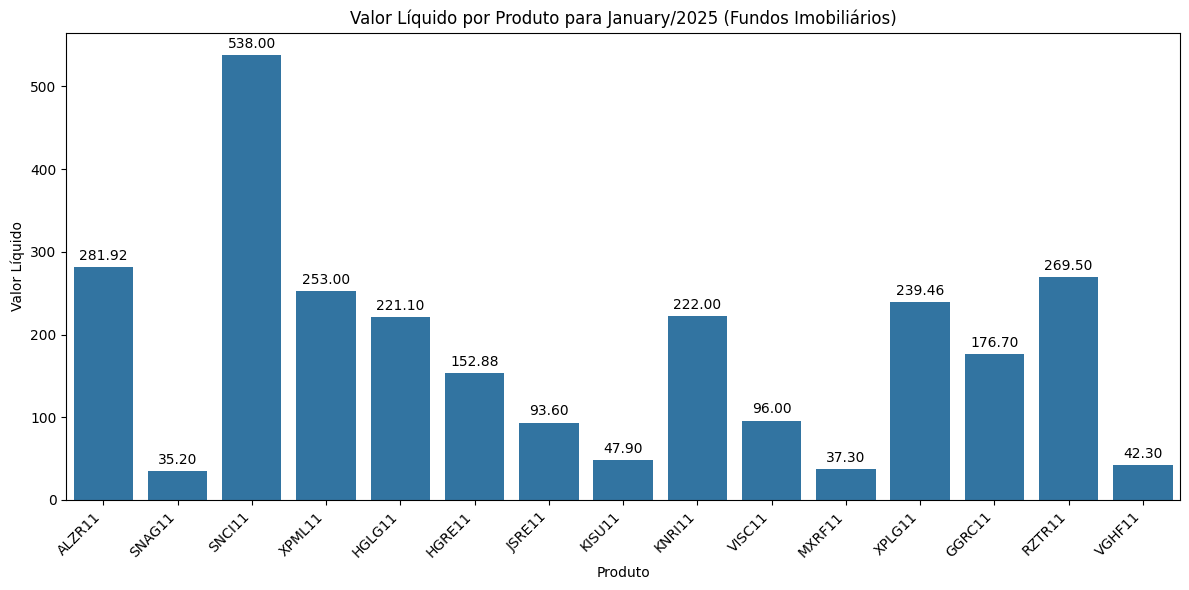

### Proventos para January/2025 (Fundos Imobiliários)

--------------------------------------------------



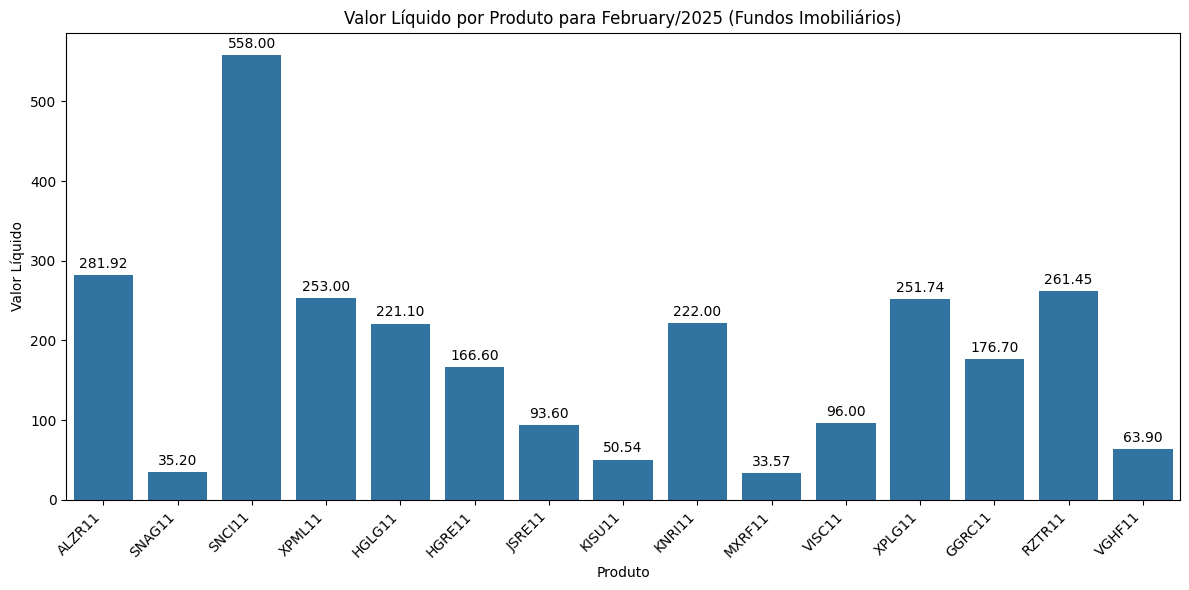

### Proventos para February/2025 (Fundos Imobiliários)

--------------------------------------------------



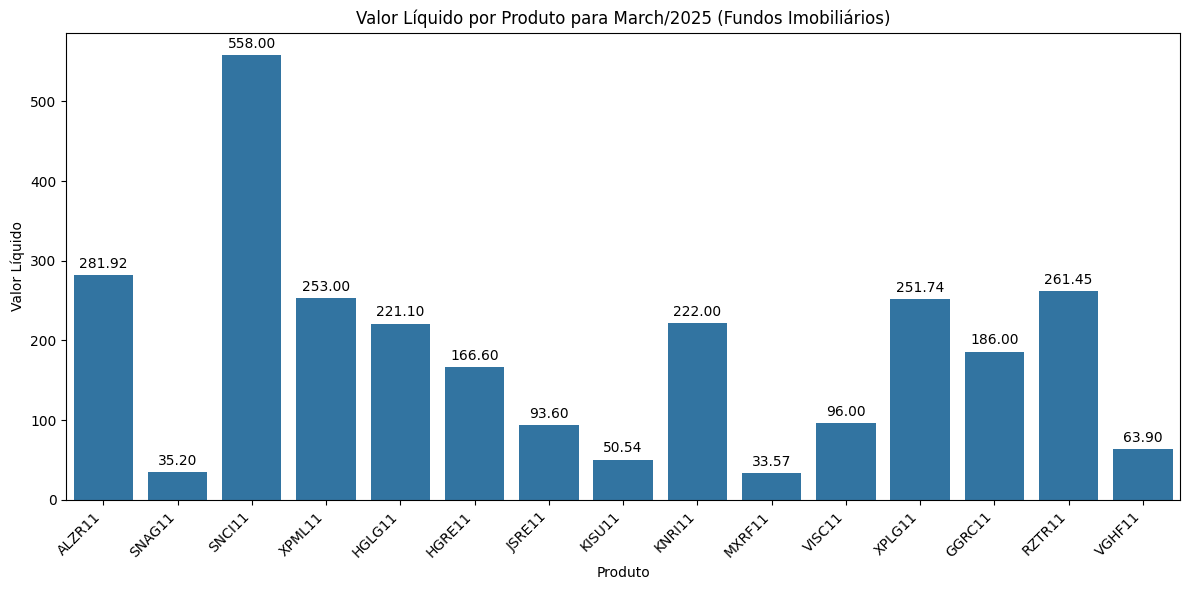

### Proventos para March/2025 (Fundos Imobiliários)

--------------------------------------------------



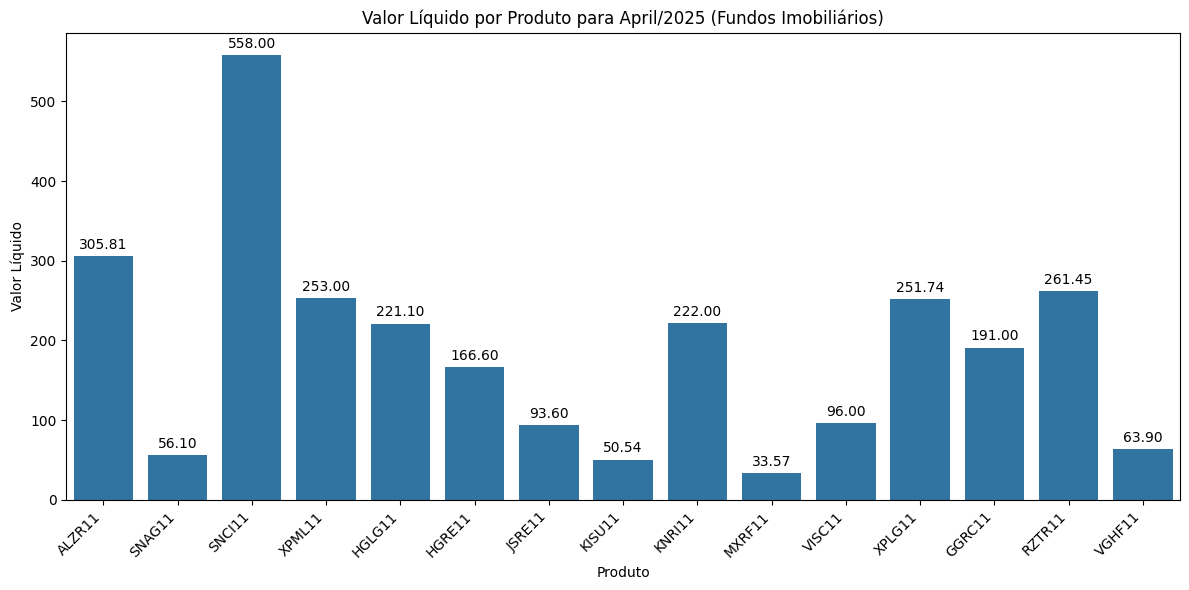

### Proventos para April/2025 (Fundos Imobiliários)

--------------------------------------------------



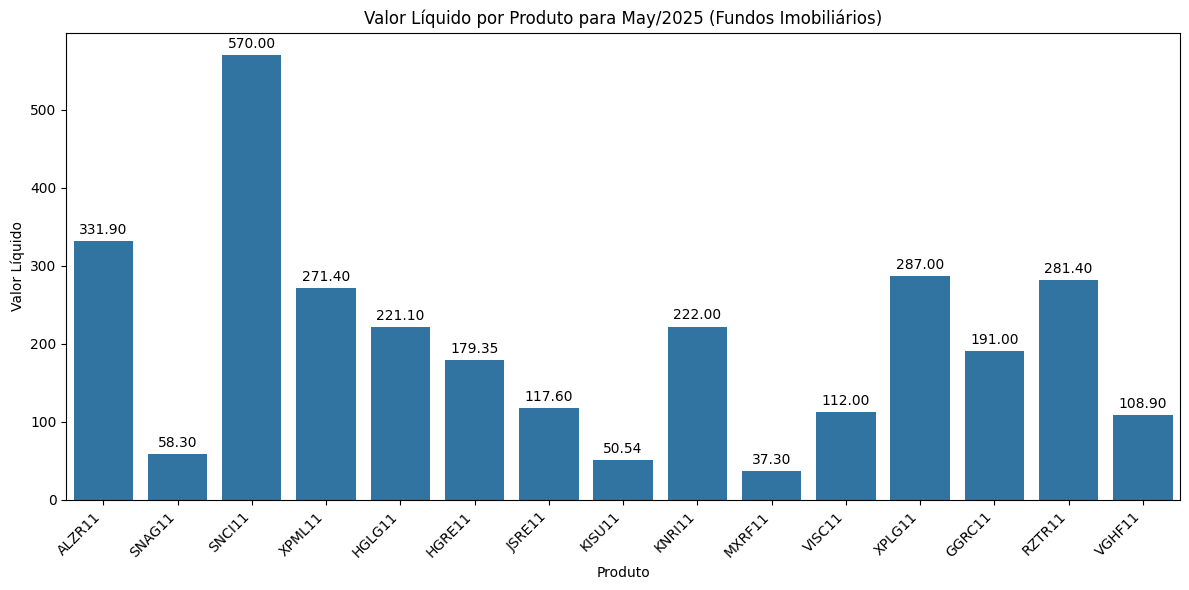

### Proventos para May/2025 (Fundos Imobiliários)

--------------------------------------------------



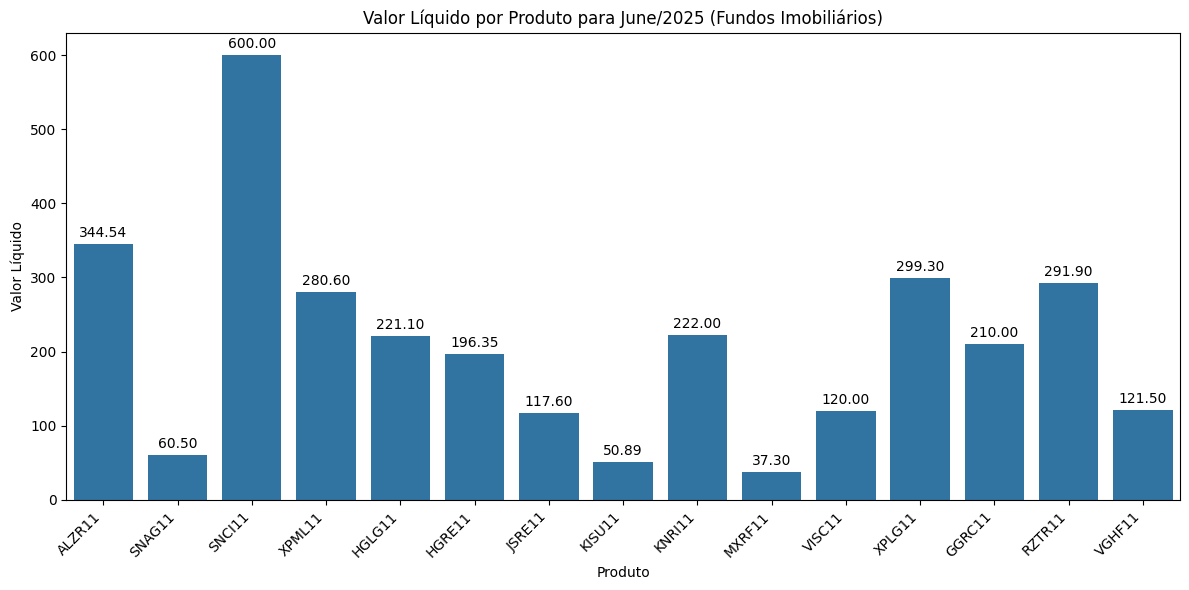

### Proventos para June/2025 (Fundos Imobiliários)

--------------------------------------------------



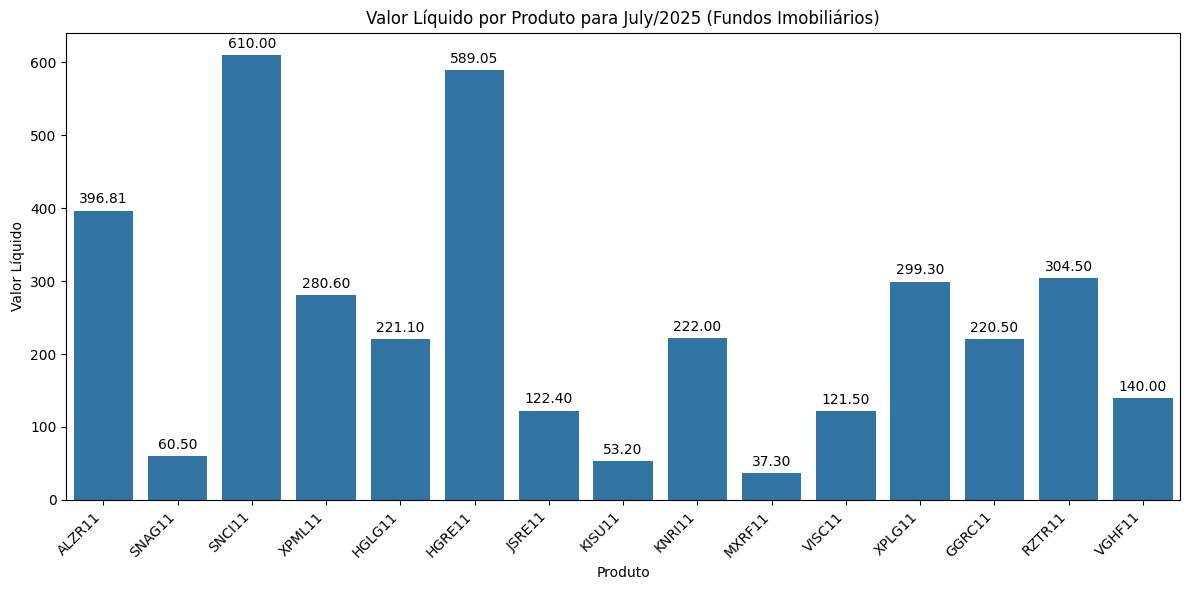

### Proventos para July/2025 (Fundos Imobiliários)

--------------------------------------------------



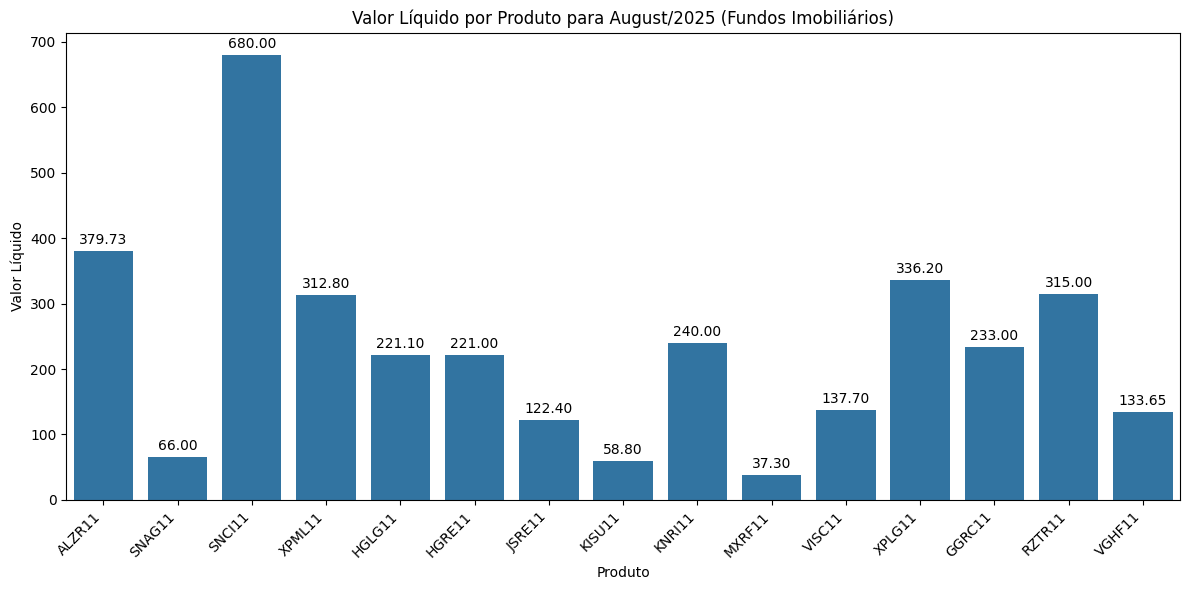

### Proventos para August/2025 (Fundos Imobiliários)

--------------------------------------------------



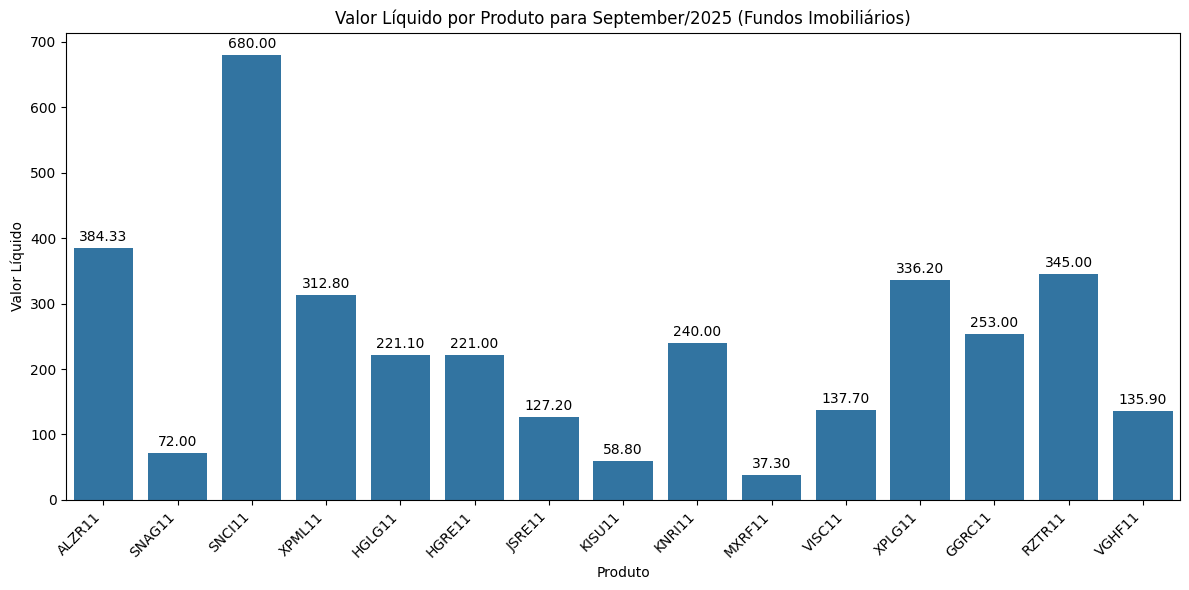

### Proventos para September/2025 (Fundos Imobiliários)

--------------------------------------------------



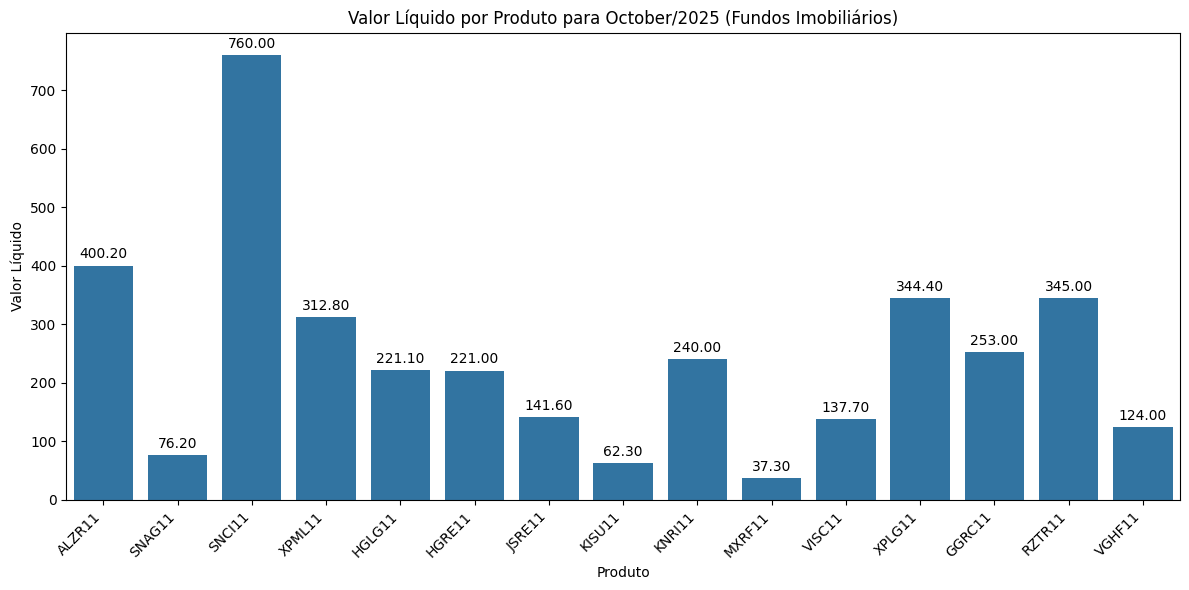

### Proventos para October/2025 (Fundos Imobiliários)

--------------------------------------------------



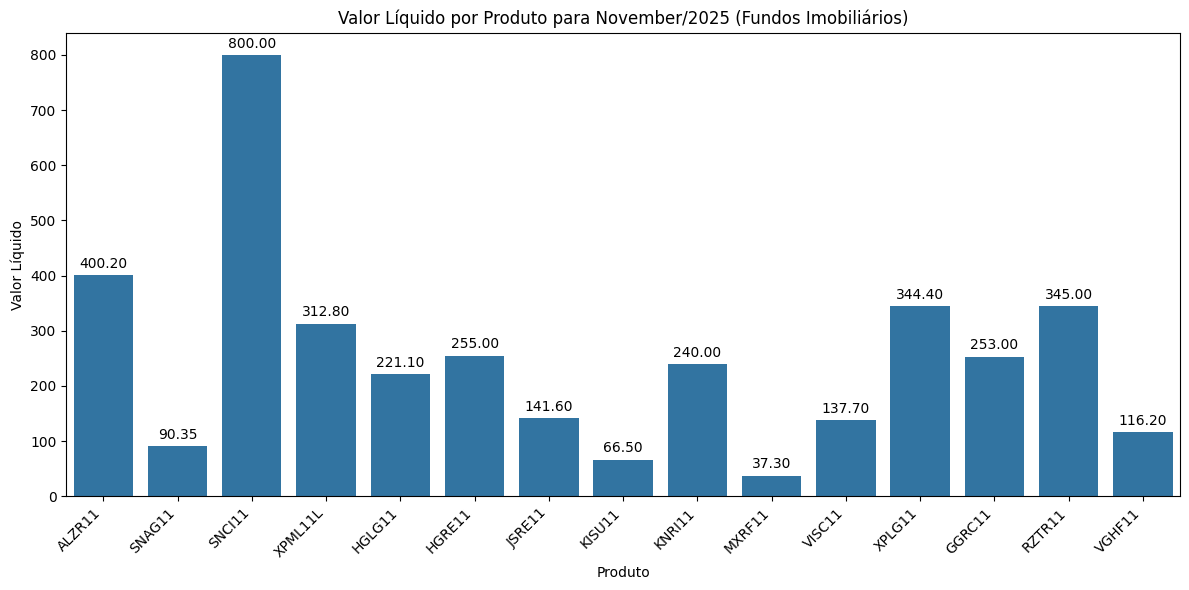

### Proventos para November/2025 (Fundos Imobiliários)

--------------------------------------------------



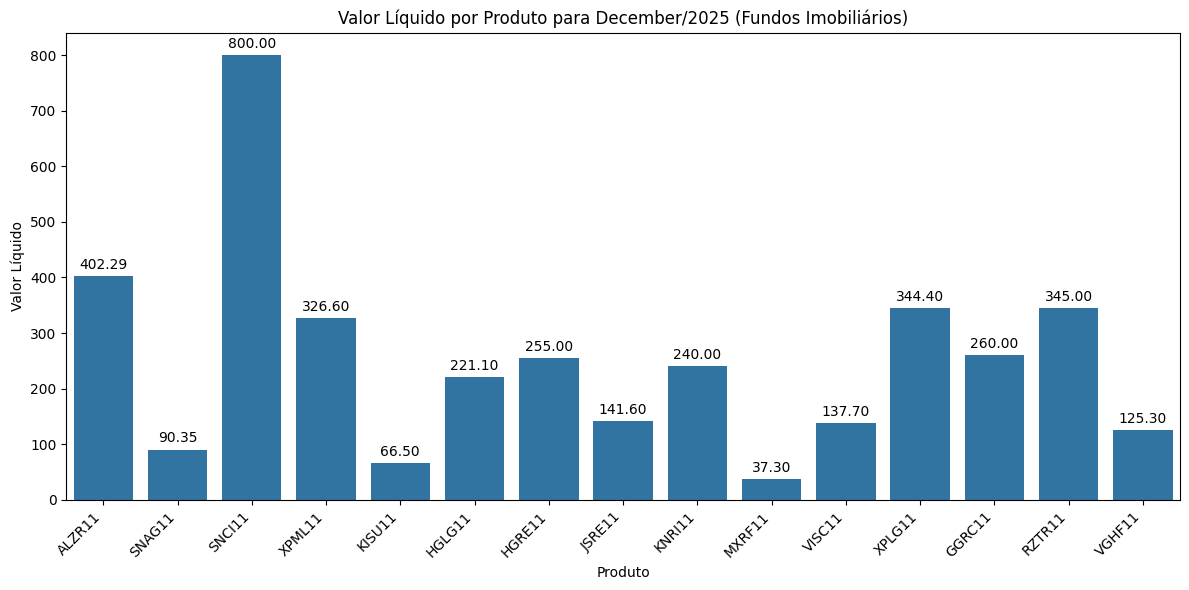

### Proventos para December/2025 (Fundos Imobiliários)

--------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Pagamento' column is in datetime format
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for real estate funds (FIIs) based on keywords in 'Produto'
df_proventos_fii = df_proventos[df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Extract month and year for grouping, dropping NaT values
df_proventos_fii['Ano_Mes'] = df_proventos_fii['Pagamento'].dt.to_period('M')

# Get unique months for iteration and sort them, excluding any NaT values
meses_unicos_proventos = pd.PeriodIndex(df_proventos_fii['Ano_Mes'].dropna().unique()).sort_values()

# Iterate through each unique month and create a bar chart
for ano_mes_prov in meses_unicos_proventos:
    # Filter data for the current month
    df_mes_proventos = df_proventos_fii[df_proventos_fii['Ano_Mes'] == ano_mes_prov].copy()

    # Drop the 'Ano_Mes' column as it's no longer needed for display
    df_mes_proventos = df_mes_proventos.drop(columns=['Ano_Mes'])

    # Extract only the first word from the 'Produto' column for plotting
    df_mes_proventos['Produto_Curto'] = df_mes_proventos['Produto'].apply(lambda x: x.split(' ')[0])

    # Calculate the total Valor líquido for the month, using Python's built-in round()
    total_liquido_mes = round(df_mes_proventos['Valor líquido'].sum(), 2)

    # Create a DataFrame for the total row
    df_total_liquido = pd.DataFrame([['Recebido total do Mês', '', '', '', '', '', total_liquido_mes]],
                                    columns=df_mes_proventos.columns[:-1]) # Exclude "Produto_Curto" column

    # Append the total row to the monthly DataFrame
    df_mes_final_proventos = pd.concat([df_mes_proventos.drop(columns=['Produto_Curto']), df_total_liquido], ignore_index=True)

    # Generate and display the bar chart
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Produto_Curto', y='Valor líquido', data=df_mes_proventos) # Use the new short product name

    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

    plt.title(f'Valor Líquido por Produto para {ano_mes_prov.strftime('%B/%Y')} (Fundos Imobiliários)')
    plt.xlabel('Produto')
    plt.ylabel('Valor Líquido')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Display the table for the current month
    print(f"### Proventos para {ano_mes_prov.strftime('%B/%Y')} (Fundos Imobiliários)")
    # display(df_mes_final_proventos)
    print("\n" + "-"*50 + "\n") # Separator for readability


/tmp/ipython-input-3011312435.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Produto_Curto', y='Valor líquido', data=df_fii_annual_total, palette='viridis')


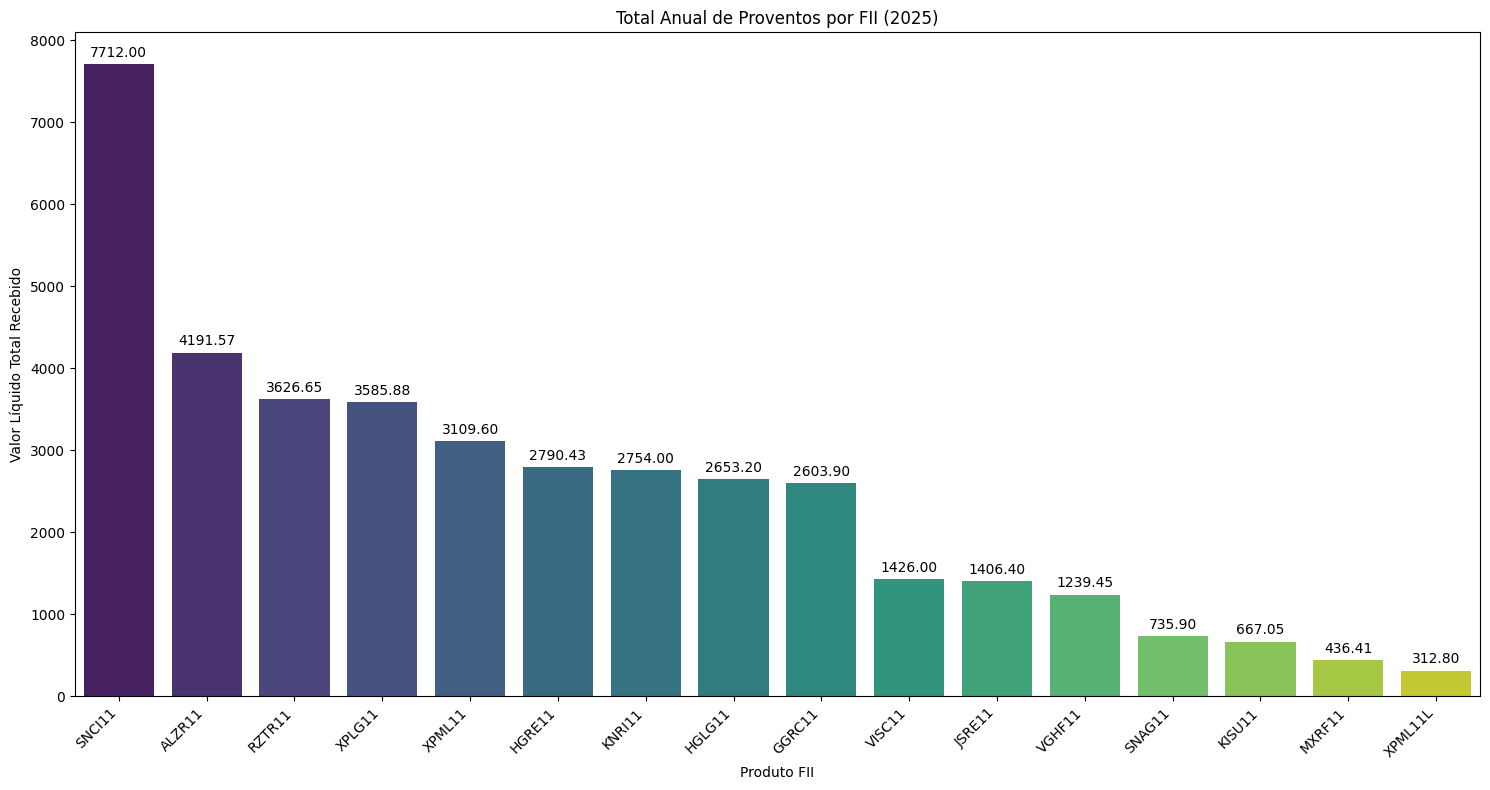

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Pagamento' column is in datetime format
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for real estate funds (FIIs) based on keywords in 'Produto'
df_proventos_fii_all = df_proventos[df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Extract only the first word from the 'Produto' column for plotting
df_proventos_fii_all['Produto_Curto'] = df_proventos_fii_all['Produto'].apply(lambda x: x.split(' ')[0])

# Aggregate 'Valor líquido' by 'Produto_Curto' for the entire year
df_fii_annual_total = df_proventos_fii_all.groupby('Produto_Curto')['Valor líquido'].sum().reset_index()

# Sort the values for better visualization (optional)
df_fii_annual_total = df_fii_annual_total.sort_values(by='Valor líquido', ascending=False)

# Plotting the bar chart
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Produto_Curto', y='Valor líquido', data=df_fii_annual_total, palette='viridis')

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.title('Total Anual de Proventos por FII (2025)')
plt.xlabel('Produto FII')
plt.ylabel('Valor Líquido Total Recebido')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exportando tabelas para CSV

In [ ]:
# Exportando df_negociacoes
df_negociacoes.to_csv('negociacoes_originais.csv', index=False)
print('negociacoes_originais.csv exportado com sucesso!')

# Exportando df_2025_final
df_2025_final.to_csv('negociacoes_anuais_2025.csv', index=False)
print('negociacoes_anuais_2025.csv exportado com sucesso!')

# Exportando df_relatorio_consolidado
df_relatorio_consolidado.to_csv('relatorio_consolidado_2025.csv', index=False)
print('relatorio_consolidado_2025.csv exportado com sucesso!')

# Exportando df_movimentacao
df_movimentacao.to_csv('movimentacao_detalhada.csv', index=False)
print('movimentacao_detalhada.csv exportado com sucesso!')

# Exportando df_proventos
df_proventos.to_csv('proventos_originais.csv', index=False)
print('proventos_originais.csv exportado com sucesso!')

# Exportando df_fii_monthly_agg
df_fii_monthly_agg.to_csv('proventos_fiis_mensais_agregados.csv', index=True) # index=True para manter o Ano_Mes
print('proventos_fiis_mensais_agregados.csv exportado com sucesso!')

# Exportando df_non_fii_monthly_agg
df_non_fii_monthly_agg.to_csv('proventos_acoes_mensais_agregados.csv', index=True) # index=True para manter o Ano_Mes
print('proventos_acoes_mensais_agregados.csv exportado com sucesso!')

negociacoes_originais.csv exportado com sucesso!
negociacoes_anuais_2025.csv exportado com sucesso!
relatorio_consolidado_2025.csv exportado com sucesso!
movimentacao_detalhada.csv exportado com sucesso!
proventos_originais.csv exportado com sucesso!
proventos_fiis_mensais_agregados.csv exportado com sucesso!
proventos_acoes_mensais_agregados.csv exportado com sucesso!


In [ ]:
import pandas as pd

# Re-create df_fii_monthly_agg
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')
df_proventos_fii_all = df_proventos[df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()
df_proventos_fii_all['Ano_Mes'] = df_proventos_fii_all['Pagamento'].dt.to_period('M')
df_proventos_fii_all['Produto_Curto'] = df_proventos_fii_all['Produto'].apply(lambda x: x.split(' ')[0])
df_fii_monthly_agg = df_proventos_fii_all.groupby(['Ano_Mes', 'Produto_Curto'])['Valor líquido'].sum().unstack(fill_value=0)

# Re-create df_non_fii_monthly_agg
df_proventos_non_fii_all = df_proventos[~df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()
df_proventos_non_fii_all['Produto'] = df_proventos_non_fii_all['Produto'].astype(str)
df_proventos_non_fii_all['Ano_Mes'] = df_proventos_non_fii_all['Pagamento'].dt.to_period('M')
df_proventos_non_fii_all['Produto_Curto'] = df_proventos_non_fii_all['Produto'].apply(lambda x: x.split(' ')[0])
df_non_fii_monthly_agg = df_proventos_non_fii_all.groupby(['Ano_Mes', 'Produto_Curto'])['Valor líquido'].sum().unstack(fill_value=0)

## Grafico com rendimento anual dos FIIs

<Figure size 1500x800 with 0 Axes>

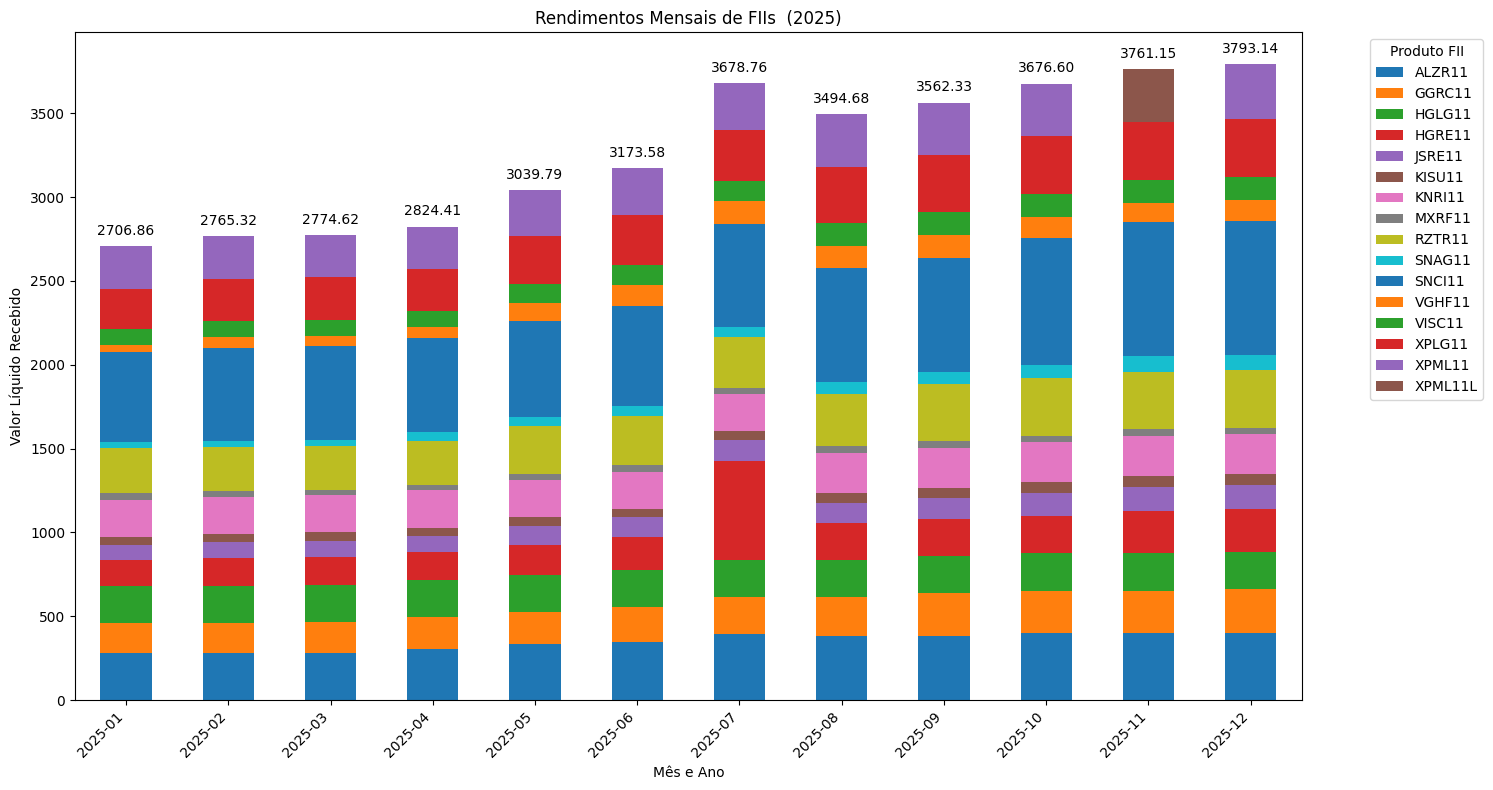

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Pagamento' column is in datetime format and 'Ano_Mes' is created
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for real estate funds (FIIs) based on keywords in 'Produto'
df_proventos_fii_all = df_proventos[df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Extract month and year for grouping, dropping NaT values
df_proventos_fii_all['Ano_Mes'] = df_proventos_fii_all['Pagamento'].dt.to_period('M')

# Extract only the first word from the 'Produto' column for plotting
df_proventos_fii_all['Produto_Curto'] = df_proventos_fii_all['Produto'].apply(lambda x: x.split(' ')[0])

# Aggregate 'Valor líquido' by month and product
df_fii_monthly_agg = df_proventos_fii_all.groupby(['Ano_Mes', 'Produto_Curto'])['Valor líquido'].sum().unstack(fill_value=0)

# Convert 'Ano_Mes' to string for better display on the x-axis
df_fii_monthly_agg.index = df_fii_monthly_agg.index.strftime('%Y-%m')

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
ax = df_fii_monthly_agg.plot(kind='bar', stacked=True, figsize=(15, 8))

# Add total value on top of each bar
for i, total_value in enumerate(df_fii_monthly_agg.sum(axis=1)):
    ax.text(i, total_value + 50, f'{total_value:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Rendimentos Mensais de FIIs  (2025)')
plt.xlabel('Mês e Ano')
plt.ylabel('Valor Líquido Recebido')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Produto FII', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Tabelas de rendimento de Ações

In [ ]:
import pandas as pd

# Ensure 'Pagamento' column is in datetime format
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for non-real estate funds (excluding FIIs)
df_proventos_non_fii = df_proventos[~df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Extract month and year for grouping, dropping NaT values
df_proventos_non_fii['Ano_Mes'] = df_proventos_non_fii['Pagamento'].dt.to_period('M')

# Get unique months for iteration and sort them, excluding any NaT values
meses_unicos_non_fii = pd.PeriodIndex(df_proventos_non_fii['Ano_Mes'].dropna().unique()).sort_values()

# Iterate through each unique month and create a table
for ano_mes_non_fii in meses_unicos_non_fii:
    # Filter data for the current month
    df_mes_non_fii = df_proventos_non_fii[df_proventos_non_fii['Ano_Mes'] == ano_mes_non_fii].copy()

    # Drop the 'Ano_Mes' column as it's no longer needed for display
    df_mes_non_fii = df_mes_non_fii.drop(columns=['Ano_Mes'])

    # Calculate the total Valor líquido for the month, using Python's built-in round()
    total_liquido_mes_non_fii = round(df_mes_non_fii['Valor líquido'].sum(), 2)

    # Create a DataFrame for the total row
    # df_mes_non_fii now has 7 columns: 'Produto', 'Pagamento', 'Tipo de Evento', 'Instituição', 'Quantidade', 'Preço unitário', 'Valor líquido'
    # So, we need 6 empty strings before 'total_liquido_mes_non_fii' to match the 7 columns
    df_total_liquido_non_fii = pd.DataFrame([['Recebido total do Mês', '', '', '', '', '', total_liquido_mes_non_fii]],
                                    columns=df_mes_non_fii.columns)

    # Append the total row to the monthly DataFrame
    df_mes_final_non_fii = pd.concat([df_mes_non_fii, df_total_liquido_non_fii], ignore_index=True)

    # Display the table for the current month
    print(f"### Proventos para {ano_mes_non_fii.strftime('%B/%Y')} (Outros Produtos)")
    display(df_mes_final_non_fii)
    print("\n" + "-"*50 + "\n") # Separator for readability


### Proventos para January/2025 (Outros Produtos)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,DISB34 - THE WALT DISNEY COMPANY,2025-01-27 00:00:00,Dividendo,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",202,0.13,26.78
1,"B3SA3 - B3 S.A. - BRASIL, BOLSA, BALCÃO",2025-01-08 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,197,0.06,10.72
2,ITSA4 - ITAUSA S/A,2025-01-02 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CORRETORA DE CAMBIO TITULOS E...,323,0.02,6.46
3,Recebido total do Mês,,,,,,43.96



--------------------------------------------------

### Proventos para February/2025 (Outros Produtos)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,EGIE3 - ENGIE BRASIL ENERGIA S.A.,2025-02-07 00:00:00,Juros Sobre Capital Próprio,"XP INVESTIMENTOS CORRETORA DE CAMBIO, TITULOS ...",125,0.31,32.55
1,Recebido total do Mês,,,,,,32.55



--------------------------------------------------

### Proventos para March/2025 (Outros Produtos)


...


--------------------------------------------------

### Proventos para October/2025 (Outros Produtos)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,"B3SA3 - B3 S.A. - BRASIL, BOLSA, BALCÃO",2025-10-07 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,197,0.08,13.11
1,ITSA4 - ITAUSA S.A.,2025-10-01 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,339,0.02,6.78
2,Recebido total do Mês,,,,,,19.89



--------------------------------------------------

### Proventos para December/2025 (Outros Produtos)


,Produto,Pagamento,Tipo de Evento,Instituição,Quantidade,Preço unitário,Valor líquido
0,RADL3 - RAIA DROGASIL S.A.,2025-12-29 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,209,0.08,15.86
1,GRND3 - GRENDENE S/A,2025-12-26 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,390,0.05,16.54
2,GRND3 - GRENDENE S/A,2025-12-26 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,390,0.06,24.32
3,EGIE3 - ENGIE BRASIL ENERGIA S.A.,2025-12-23 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,125,0.88,109.56
4,EGIE3 - ENGIE BRASIL ENERGIA S.A.,2025-12-23 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,125,0.88,110.17
5,GOGL34 - ALPHABET INC.,2025-12-19 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,84,0.07,5.41
6,ITSA4 - ITAUSA S.A.,2025-12-19 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,339,0.78,262.84
7,EVTC31 - EVERTEC INC,2025-12-12 00:00:00,Dividendo,XP INVESTIMENTOS CCTVM S/A,1,0.26,0.26
8,WEGE3 - WEG S.A.,2025-12-12 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,326,0.11,30.55
9,WEGE3 - WEG S.A.,2025-12-12 00:00:00,Juros Sobre Capital Próprio,XP INVESTIMENTOS CCTVM S/A,326,0.11,30.84



--------------------------------------------------



## Gráfico com rendimentos mensais de Acões

<Figure size 1500x800 with 0 Axes>

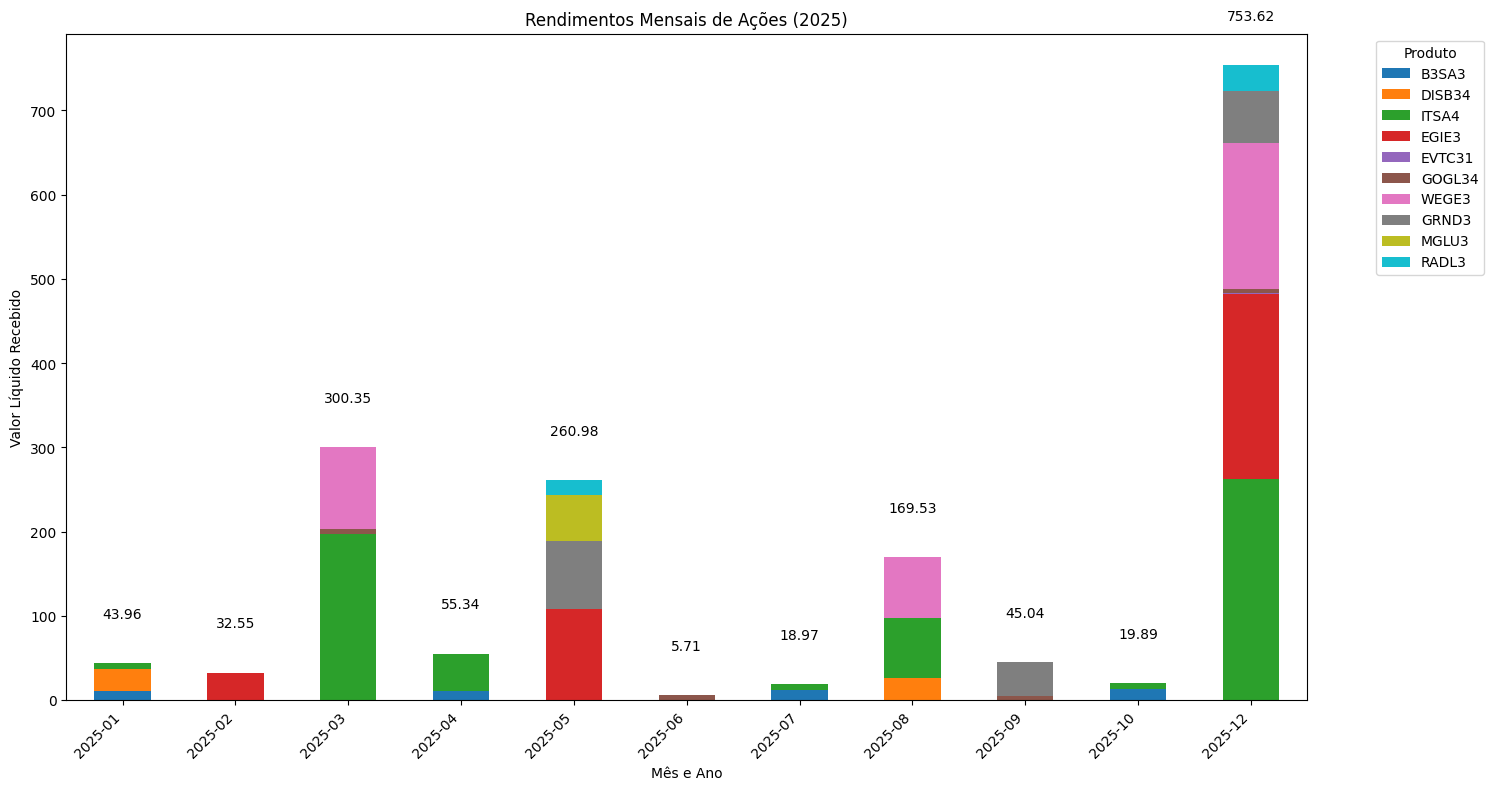

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Pagamento' column is in datetime format
df_proventos['Pagamento'] = pd.to_datetime(df_proventos['Pagamento'], format='%d/%m/%Y')

# Filter for non-real estate funds (excluding FIIs)
df_proventos_non_fii_all = df_proventos[~df_proventos['Produto'].str.contains('FII|FDO|INV|IMOB', na=False, case=False)].copy()

# Ensure 'Produto' column is string type to avoid AttributeError with .split()
df_proventos_non_fii_all['Produto'] = df_proventos_non_fii_all['Produto'].astype(str)

# Extract month and year for grouping, dropping NaT values
df_proventos_non_fii_all['Ano_Mes'] = df_proventos_non_fii_all['Pagamento'].dt.to_period('M')

# Extract only the first word from the 'Produto' column for plotting
df_proventos_non_fii_all['Produto_Curto'] = df_proventos_non_fii_all['Produto'].apply(lambda x: x.split(' ')[0])

# Aggregate 'Valor líquido' by month and product
df_non_fii_monthly_agg = df_proventos_non_fii_all.groupby(['Ano_Mes', 'Produto_Curto'])['Valor líquido'].sum().unstack(fill_value=0)

# Convert 'Ano_Mes' to string for better display on the x-axis
df_non_fii_monthly_agg.index = df_non_fii_monthly_agg.index.strftime('%Y-%m')

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
ax = df_non_fii_monthly_agg.plot(kind='bar', stacked=True, figsize=(15, 8))

# Add total value on top of each bar
for i, total_value in enumerate(df_non_fii_monthly_agg.sum(axis=1)):
    ax.text(i, total_value + 50, f'{total_value:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Rendimentos Mensais de Ações (2025)')
plt.xlabel('Mês e Ano')
plt.ylabel('Valor Líquido Recebido')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()